In [1]:
# Configuration

# --- Standard Libraries ---
import sys
gems_tco_path = "/Users/joonwonlee/Documents/GEMS_TCO-1/src"
import os
import json
import time
import copy
import cmath
import pickle
import logging
import argparse

# Path configuration (only run once)
sys.path.append(gems_tco_path)

# --- Third-Party Libraries ---
from pathlib import Path
from typing import Optional, List, Tuple, Dict, Any, Callable
from json import JSONEncoder

# Data manipulation and analysis
import pandas as pd
import numpy as np
from sklearn.neighbors import BallTree
import typer

# Torch and Numerical Libraries
import torch
import torch.optim as optim
import torch.fft
import torch.nn.functional as F
from torch.nn import Parameter
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import matplotlib.pyplot as plt 

# --- Custom (GEMS_TCO) Imports ---
import GEMS_TCO
from GEMS_TCO import kernels_reparam_space_time_gpu
from GEMS_TCO import data_preprocess, data_preprocess as dmbh
from GEMS_TCO import orderings as _orderings 

from GEMS_TCO import alg_optimization
from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import  exact_location_filter, load_data_dynamic_processed 
from GEMS_TCO import debiased_whittle


load monthly data — 2022, 2023, 2024, 2025

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
MONTH     = 7
YEARS     = ['2022', '2023', '2024', '2025']
MM_COND   = 8

data_load_instance = load_data_dynamic_processed(config.mac_data_load_path)

# Load raw tensors per year  (DW: keep_ori=False → grid coords)
tensors_dw_by_year = {}
maps_dw_by_year    = {}

for year in YEARS:
    df_map, ord_mm, nns_map, monthly_mean = data_load_instance.load_maxmin_ordered_data_bymonthyear(
        lat_lon_resolution=[1, 1],
        mm_cond_number=MM_COND,
        years_=[year],
        months_=[MONTH],
        lat_range=LAT_RANGE,
        lon_range=LON_RANGE,
        is_whittle=False
    )
    daily_tensors, daily_maps = [], []
    for day_index in range(28):
        hour_indices = [day_index * 8, (day_index + 1) * 8]
        day_map, day_tensor = data_load_instance.load_working_data(
            df_map, monthly_mean, hour_indices,
            ord_mm=None, dtype=torch.float64, keep_ori=False
        )
        daily_tensors.append(day_tensor)
        daily_maps.append(day_map)

    tensors_dw_by_year[year] = daily_tensors
    maps_dw_by_year[year]    = daily_maps
    print(f"  {year}: {len(daily_tensors)} days loaded,  shape={daily_tensors[0].shape}")


--- Global Monthly Mean for 2022-7: 250.6500 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2022: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2023-7: 249.7131 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2023: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2024-7: 257.9726 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2024: 28 days loaded,  shape=torch.Size([145008, 11])
--- Global Monthly Mean for 2025-7: 241.4412 ---
--- Generating NNS Map for Vecchia (C++ Accelerated) ---
  2025: 28 days loaded,  shape=torch.Size([145008, 11])


In [3]:
# ── Estimates loading ──────────────────────────────────────────────────────
V_GRID_LON = -0.0048   # grid velocity correction for DW advec_lon
PARAM_COLS = ['sigma_sq', 'range_lat', 'range_lon', 'range_time',
              'advec_lat', 'advec_lon', 'nugget']

EST_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/july_22_23_24_25/")
dw_raw   = pd.read_csv(EST_PATH / "real_dw_july_22_23_24_25.csv")
vecc_raw = pd.read_csv(EST_PATH / "real_vecc_july_22_23_24_25_mm20.csv")
cauchy_raw = pd.read_csv(EST_PATH / "real_cauchy_b10_july_22_23_24_25_mm20.csv")

_RAW_PARAM_COLS = ['sigma', 'range_lat', 'range_lon', 'range_time',
                   'advec_lat', 'advec_lon', 'nugget']

def split_estimates_by_year(df, years=YEARS, n_days=28):
    """Split combined CSV into per-year DataFrames, indexed 0..n_days-1.
    Parses year and day-of-month from the 'day' column (e.g. '2023-07-6').
    Missing days are filled with NaN rows so positional day_idx access stays
    correct even when some days failed to converge on Amarel."""
    df = df.copy()
    df['_year']    = df['day'].astype(str).str[:4]
    df['_day_num'] = df['day'].astype(str).str.extract(r'-(\d+)$')[0].astype(int)
    result = {}
    for yr in years:
        sub = (df[df['_year'] == yr]
               .set_index('_day_num')[_RAW_PARAM_COLS]
               .reindex(range(1, n_days + 1)))   # NaN rows for missing days
        sub.columns = PARAM_COLS
        result[yr] = sub.reset_index(drop=True)
    return result


dw_by_year   = split_estimates_by_year(dw_raw)
vecc_by_year = split_estimates_by_year(vecc_raw)
cauchy_by_year = split_estimates_by_year(cauchy_raw)
# Apply grid velocity correction to DW advec_lon
for yr in YEARS:
    dw_by_year[yr]['advec_lon'] = dw_by_year[yr]['advec_lon'] + V_GRID_LON

for yr in YEARS:
    print(f"  {yr}  DW rows={len(dw_by_year[yr])}  Vecc rows={len(vecc_by_year[yr])}  Cauchy rows={len(cauchy_by_year[yr])}")


  2022  DW rows=28  Vecc rows=28  Cauchy rows=28
  2023  DW rows=28  Vecc rows=28  Cauchy rows=28
  2024  DW rows=28  Vecc rows=28  Cauchy rows=28
  2025  DW rows=28  Vecc rows=28  Cauchy rows=28


In [5]:
# ── CSV Export ──────────────────────────────────────────────────────────────
OUT_DIR = Path("/Users/joonwonlee/Documents/diagnostic_plot_data_dynamic_grid")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Extract day numbers from raw CSVs (1-based, from 'day' column like '2022-07-1')
vecc_raw['day_num'] = vecc_raw['day'].str.extract(r'-(\d+)$')[0].astype(int)
vecc_raw['year_str'] = vecc_raw['day'].str[:4]
dw_raw['day_num']   = dw_raw['day'].str.extract(r'-(\d+)$')[0].astype(int)
dw_raw['year_str']  = dw_raw['day'].str[:4]
cauchy_raw['day_num']  = cauchy_raw['day'].str.extract(r'-(\d+)$')[0].astype(int)
cauchy_raw['year_str'] = cauchy_raw['day'].str[:4]
                                               
for yr in YEARS:
    vecc_days = vecc_raw[vecc_raw['year_str'] == yr]['day_num'].reset_index(drop=True)
    dw_days   = dw_raw[dw_raw['year_str'] == yr]['day_num'].reset_index(drop=True)
    cauchy_days = cauchy_raw[cauchy_raw['year_str'] == yr]['day_num'].reset_index(drop=True)

    vecc_out = vecc_by_year[yr].copy()
    vecc_out.insert(0, 'day', vecc_days)
    vecc_out.to_csv(OUT_DIR / f"vecc_by_year_{yr}.csv", index=False, float_format='%.4f')

    dw_out = dw_by_year[yr].copy()
    dw_out.insert(0, 'day', dw_days)
    dw_out.to_csv(OUT_DIR / f"dw_by_year_{yr}.csv", index=False, float_format='%.4f')

    cauchy_out = cauchy_by_year[yr].copy()
    cauchy_out.insert(0, 'day', cauchy_days)
    cauchy_out.to_csv(OUT_DIR / f"cauchy_by_year_{yr}.csv", index=False, float_format='%.4f')   

print(f"Saved CSV files to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")

Saved CSV files to: /Users/joonwonlee/Documents/diagnostic_plot_data_dynamic_grid
  cauchy_by_year_2022.csv
  cauchy_by_year_2023.csv
  cauchy_by_year_2024.csv
  cauchy_by_year_2025.csv
  dw_by_year_2022.csv
  dw_by_year_2023.csv
  dw_by_year_2024.csv
  dw_by_year_2025.csv
  vecc_by_year_2022.csv
  vecc_by_year_2023.csv
  vecc_by_year_2024.csv
  vecc_by_year_2025.csv


In [10]:
dw_raw

,day,cov_name,space_size,lr,sigma,range_lat,range_lon,range_time,advec_lat,advec_lon,nugget,loss,time,rmsre,day_num,year_str
0,2022-07-1,DW_Real,18126.0000,1.0000,3.5972,0.1418,0.2201,1.2601,-0.0156,0.0799,2.4864,115551.0880,111.7636,0.0000,1,2022
1,2022-07-2,DW_Real,18126.0000,1.0000,6.4137,0.1200,0.1311,0.8784,0.0299,-0.2897,1.4776,246956.5280,94.1755,0.0000,2,2022
2,2022-07-3,DW_Real,18126.0000,1.0000,5.9562,0.1507,0.1610,0.8402,0.0092,-0.0588,1.0284,-79128.9280,75.2054,0.0000,3,2022
3,2022-07-4,DW_Real,18126.0000,1.0000,6.1565,0.1759,0.1635,1.1198,0.0312,-0.2129,2.0101,224817.5680,82.9525,0.0000,4,2022
4,2022-07-5,DW_Real,18126.0000,1.0000,5.2483,0.1396,0.1333,1.1900,0.0330,-0.2063,1.0364,-80700.0800,77.4687,0.0000,5,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,2025-07-24,DW_Real,18126.0000,1.0000,2.7881,0.1101,0.1330,1.6708,0.0001,0.0002,1.4162,-310802.4320,111.4777,0.0000,24,2025
108,2025-07-25,DW_Real,18126.0000,1.0000,5.5846,0.1351,0.1671,2.7386,0.0001,0.0001,1.1227,-185824.4320,141.2404,0.0000,25,2025
109,2025-07-26,DW_Real,18126.0000,1.0000,10.6778,0.1432,0.2305,0.8937,0.0109,-0.5433,0.8986,220104.1120,113.7936,0.0000,26,2025
110,2025-07-27,DW_Real,18126.0000,1.0000,13.1265,0.1553,0.1721,0.8943,-0.0301,-0.3403,0.9439,487485.6160,70.3424,0.0000,27,2025


functions setup

whitening 8 multivariate correlation 

x 축 18126*8



# sigma hat profile out

선생님께서 올려주신 코드의 핵심 문제점은 두 가지였습니다:

ratio_raw 매핑 오류: whitened_power를 추출할 때 fftshift를 거치지 않고 바로 flatten() 해버렸습니다.

Meshgrid 차원 역전 오류: g_lon, g_lat = np.meshgrid(freq_lon, freq_lat, indexing='ij') 에서 ij 인덱싱을 썼으면서 lon과 lat의 순서를 거꾸로 받아버렸습니다. (정답은 g_lat, g_lon = ... (freq_lat, freq_lon) 입니다.)

--- Processing Day Index 17 ---
Initializing Debiased Whittle Preprocessor...
Computing Debiased Whittle (Profile Sigma)...
Computing VECC (Profile Sigma)...


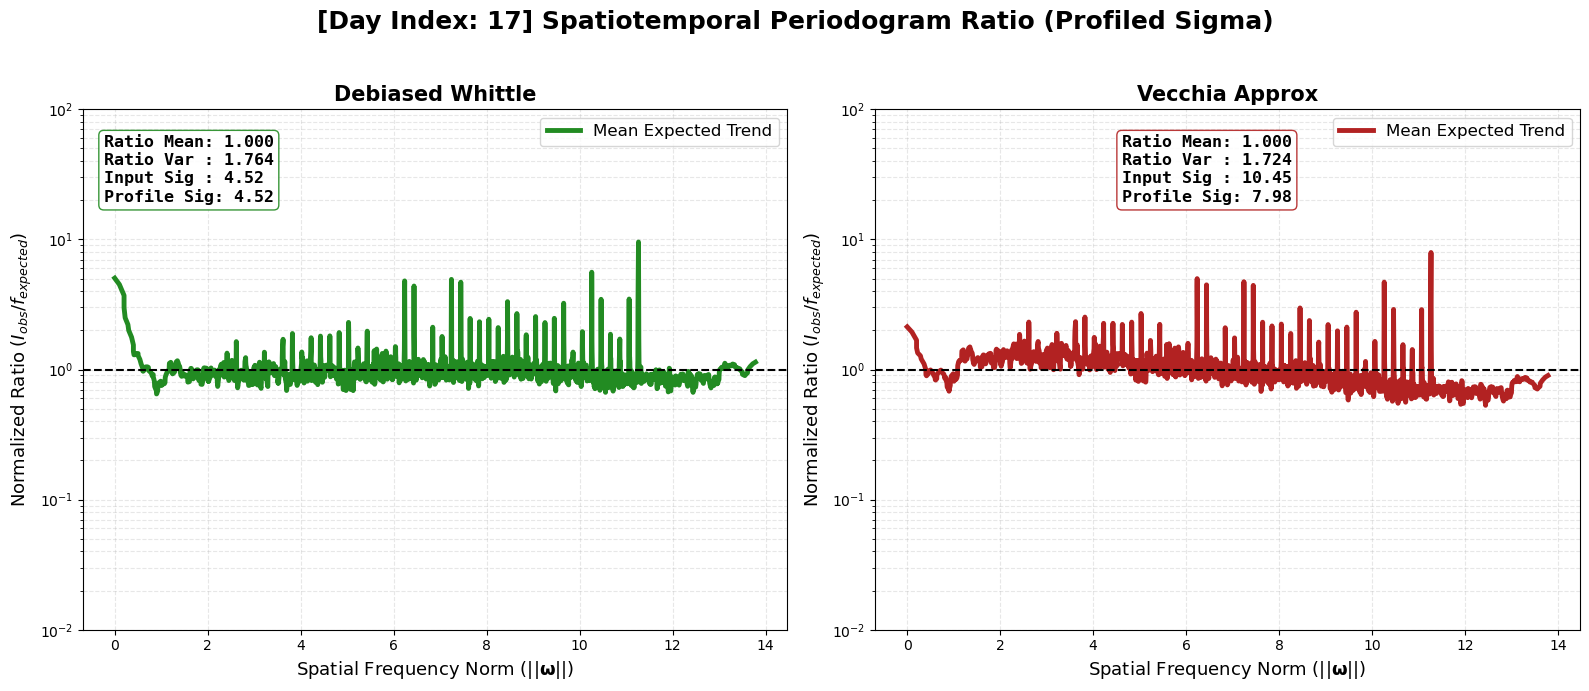

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftshift, fftfreq
from scipy.ndimage import gaussian_filter1d
import cmath
import sys
import pandas as pd

# (사용자 환경에 맞게 수정)
# from GEMS_TCO import debiased_whittle 

# =========================================================================
# 1. The Logic Class (Debiased Whittle Likelihood Core)
# =========================================================================
class debiased_whittle_likelihood:
    
    @staticmethod
    def cgn_hamming(u, n1, n2):
        u1, u2 = u
        device = u1.device if isinstance(u1, torch.Tensor) else (u2.device if isinstance(u2, torch.Tensor) else torch.device('cpu'))
        u1_tensor = u1.to(device) if isinstance(u1, torch.Tensor) else torch.tensor(u1, device=device, dtype=torch.float64)
        u2_tensor = u2.to(device) if isinstance(u2, torch.Tensor) else torch.tensor(u2, device=device, dtype=torch.float64)
        n1_eff = float(n1) if n1 > 0 else 1.0
        n2_eff = float(n2) if n2 > 0 else 1.0
        
        hamming1 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u1_tensor / n1_eff)
        hamming2 = 0.54 - 0.46 * torch.cos(2.0 * torch.pi * u2_tensor / n2_eff)
        return hamming1 * hamming2

    @staticmethod
    def calculate_taper_autocorrelation_fft(taper_grid, n1, n2, device):
        taper_grid = taper_grid.to(device) 
        H = torch.sum(taper_grid**2)
        if H < 1e-12:
            return torch.zeros((2*n1-1, 2*n2-1), device=device, dtype=taper_grid.dtype)
        N1, N2 = 2 * n1 - 1, 2 * n2 - 1
        taper_fft = torch.fft.fft2(taper_grid, s=(N1, N2))
        power_spectrum = torch.abs(taper_fft)**2
        autocorr_unnormalized = torch.fft.ifft2(power_spectrum).real
        autocorr_shifted = torch.fft.fftshift(autocorr_unnormalized)
        return autocorr_shifted / (H + 1e-12)

    @staticmethod
    def generate_Jvector_tapered(tensor_list, tapering_func, lat_col, lon_col, val_col, device):
        p_time = len(tensor_list)
        if p_time == 0: return torch.empty(0, 0, 0, device=device, dtype=torch.complex128), 0, 0, 0, None

        valid_tensors = [t for t in tensor_list if t.numel() > 0 and t.shape[1] > max(lat_col, lon_col, val_col)]
        if not valid_tensors: return torch.empty(0, 0, 0, device=device, dtype=torch.complex128), 0, 0, 0, None

        all_lats_cpu = torch.cat([t[:, lat_col] for t in valid_tensors]).cpu()
        all_lons_cpu = torch.cat([t[:, lon_col] for t in valid_tensors]).cpu()
        
        mask = ~torch.isnan(all_lats_cpu) & ~torch.isinf(all_lats_cpu) & ~torch.isnan(all_lons_cpu) & ~torch.isinf(all_lons_cpu)
        all_lats_cpu = all_lats_cpu[mask]
        all_lons_cpu = all_lons_cpu[mask]

        unique_lats_cpu, unique_lons_cpu = torch.unique(all_lats_cpu), torch.unique(all_lons_cpu)
        n1, n2 = len(unique_lats_cpu), len(unique_lons_cpu)

        lat_map = {lat.item(): i for i, lat in enumerate(unique_lats_cpu)}
        lon_map = {lon.item(): i for i, lon in enumerate(unique_lons_cpu)}

        u1_mesh_cpu, u2_mesh_cpu = torch.meshgrid(
            torch.arange(n1, dtype=torch.float64),
            torch.arange(n2, dtype=torch.float64),
            indexing='ij'
        )
        taper_grid = tapering_func((u1_mesh_cpu, u2_mesh_cpu), n1, n2).to(device)

        fft_results = []
        for tensor in tensor_list:
            data_grid = torch.zeros((n1, n2), dtype=torch.float64, device=device)
            for row in tensor:
                lat_val, lon_val, val = row[lat_col].item(), row[lon_col].item(), row[val_col].item()
                if not (np.isnan(lat_val) or np.isnan(lon_val) or np.isnan(val)):
                    i = lat_map.get(lat_val)
                    j = lon_map.get(lon_val)
                    if i is not None and j is not None:
                        data_grid[i, j] = val

            data_grid_tapered = data_grid * taper_grid 
            data_grid_tapered = torch.nan_to_num(data_grid_tapered, nan=0.0)
            fft_results.append(torch.fft.fft2(data_grid_tapered))

        J_vector_tensor = torch.stack(fft_results, dim=2)
        H = torch.sum(taper_grid**2)
        norm_factor = (torch.sqrt(1.0 / H) / (2.0 * cmath.pi)).to(device)

        return J_vector_tensor * norm_factor, n1, n2, p_time, taper_grid

    @staticmethod
    def calculate_sample_periodogram_vectorized(J_vector_tensor):
        J_col = J_vector_tensor.unsqueeze(-1)
        J_row_conj = J_vector_tensor.unsqueeze(-2).conj()
        return J_col @ J_row_conj

    @staticmethod
    def cov_x_spatiotemporal_model_kernel(u1, u2, t, params):
        device = params.device
        u1 = torch.as_tensor(u1, device=device, dtype=torch.float64)
        u2 = torch.as_tensor(u2, device=device, dtype=torch.float64)
        t  = torch.as_tensor(t, device=device, dtype=torch.float64)

        phi1, phi2, phi3, phi4 = torch.exp(params[0]), torch.exp(params[1]), torch.exp(params[2]), torch.exp(params[3])
        advec_lat, advec_lon = params[4], params[5]
        nugget = torch.exp(params[6])

        epsilon = 1e-12
        sigmasq = phi1 / (phi2 + epsilon)
        range_lon_inv = phi2
        range_lat_inv = torch.sqrt(phi3 + epsilon) * phi2
        beta_scaled_inv = torch.sqrt(phi4 + epsilon) * phi2 

        u1_adv = u1 - advec_lat * t
        u2_adv = u2 - advec_lon * t

        dist_sq = (u1_adv * range_lat_inv).pow(2) + (u2_adv * range_lon_inv).pow(2) + (t * beta_scaled_inv).pow(2)
        distance = torch.sqrt(dist_sq + epsilon)
        
        cov_smooth = sigmasq * torch.exp(-distance)
        is_zero_lag = (torch.abs(u1) < 1e-9) & (torch.abs(u2) < 1e-9) & (torch.abs(t) < 1e-9)
        return torch.where(is_zero_lag, cov_smooth + nugget, cov_smooth)

    @staticmethod
    def cov_spatial_difference(u1, u2, t, params, delta1, delta2):
        weights = {(0, 0): -2.0, (1, 0): 1.0, (0, 1): 1.0}
        device = params.device
        cov = torch.zeros_like(u1, device=device, dtype=torch.float64)

        for (a, b), w_ab in weights.items():
            for (c, d), w_cd in weights.items():
                lag_u1 = u1 + (a - c) * delta1
                lag_u2 = u2 + (b - d) * delta2
                cov += w_ab * w_cd * debiased_whittle_likelihood.cov_x_spatiotemporal_model_kernel(lag_u1, lag_u2, t, params)
        return cov

    @staticmethod
    def cn_bar_tapered(u1, u2, t, params, n1, n2, taper_autocorr_grid, delta1, delta2):
        lag_u1 = u1 * delta1
        lag_u2 = u2 * delta2
        cov_val = debiased_whittle_likelihood.cov_spatial_difference(lag_u1, lag_u2, t, params, delta1, delta2)
        
        idx1 = torch.clamp((n1 - 1 + u1).long(), 0, 2 * n1 - 2)
        idx2 = torch.clamp((n2 - 1 + u2).long(), 0, 2 * n2 - 2)
        taper_val = taper_autocorr_grid[idx1, idx2]
        return cov_val * taper_val

    @staticmethod
    def expected_periodogram_fft_tapered(params, n1, n2, p_time, taper_autocorr_grid, delta1, delta2):
        device = params.device
        u1_mesh, u2_mesh = torch.meshgrid(
            torch.arange(n1, dtype=torch.float64, device=device),
            torch.arange(n2, dtype=torch.float64, device=device),
            indexing='ij'
        )
        t_lags = torch.arange(p_time, dtype=torch.float64, device=device)
        tilde_cn_tensor = torch.zeros((n1, n2, p_time, p_time), dtype=torch.complex128, device=device)

        for q in range(p_time):
            for r in range(p_time):
                t_diff = t_lags[q] - t_lags[r]
                t1 = debiased_whittle_likelihood.cn_bar_tapered(u1_mesh, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t2 = debiased_whittle_likelihood.cn_bar_tapered(u1_mesh - n1, u2_mesh, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t3 = debiased_whittle_likelihood.cn_bar_tapered(u1_mesh, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                t4 = debiased_whittle_likelihood.cn_bar_tapered(u1_mesh - n1, u2_mesh - n2, t_diff, params, n1, n2, taper_autocorr_grid, delta1, delta2)
                tilde_cn_tensor[:, :, q, r] = (t1 + t2 + t3 + t4).to(torch.complex128)

        # 🚨 [수정 완] .real을 제거하여 허수부(Advection Phase 정보)를 보존
        fft_result = torch.fft.fft2(tilde_cn_tensor, dim=(0, 1))
        norm_factor = 1.0 / (4.0 * cmath.pi**2)
        return fft_result * norm_factor

# =========================================================================
# 2. Calculation Helper (Profile Sigma with Corrected FFT Mapping)
# =========================================================================
def calculate_periodogram_ratio(data_tensor, params_row, device):
    """Compute whitened periodogram ratio using multivariate (mv) DW functions,
    consistent with Amarel fitting (generate_Jvector_tapered_mv + 
    calculate_taper_autocorrelation_multivariate)."""
    from GEMS_TCO import debiased_whittle as _dw
    dwl = _dw.debiased_whittle_likelihood()

    DELTA_LAT = 0.044
    DELTA_LON = 0.063
    LAT_COL, LON_COL, VAL_COL, TIME_COL = 0, 1, 2, 3

    # 1. Parameter Extraction
    try:
        sigma_sq = params_row['sigma']
    except KeyError:
        sigma_sq = params_row['sigma_sq']

    range_lat  = params_row['range_lat']
    range_lon  = params_row['range_lon']
    range_time = params_row['range_time']
    advec_lat  = params_row['advec_lat']
    advec_lon  = params_row['advec_lon']
    nugget     = params_row['nugget']
    nugget_safe = nugget if nugget > 1e-9 else 1e-15

    phi2 = 1.0 / range_lon
    phi1 = sigma_sq * phi2
    phi3 = (range_lon / range_lat) ** 2
    phi4 = (range_lon / range_time) ** 2

    params_tensor = torch.tensor([
        np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
        advec_lat, advec_lon, np.log(nugget_safe)
    ], device=device, dtype=torch.float64)

    # 2. Build time slices (data already preprocessed / mean-free)
    unique_times = torch.unique(data_tensor[:, TIME_COL])
    time_slices = [data_tensor[data_tensor[:, TIME_COL] == t] for t in unique_times]

    # 3. Multivariate J-vector (same path as Amarel fitting)
    J_vec, n1, n2, p_time, taper_grid, obs_masks = dwl.generate_Jvector_tapered_mv(
        time_slices, tapering_func=dwl.cgn_hamming,
        lat_col=LAT_COL, lon_col=LON_COL, val_col=VAL_COL, device=device
    )

    # 4. Multivariate taper autocorrelation: (p, p, 2n1-1, 2n2-1)
    taper_autocorr = dwl.calculate_taper_autocorrelation_multivariate(
        taper_grid, obs_masks, n1, n2, device
    )
    del obs_masks

    # 5. Expected periodogram: (n1, n2, p, p) — 4-D taper_autocorr handled automatically
    with torch.no_grad():
        I_expected = dwl.expected_periodogram_fft_tapered(
            params_tensor, n1, n2, p_time, taper_autocorr, DELTA_LAT, DELTA_LON
        )

    # 6. Whitening: Z = L^{-1} J,  whitened_power = |Z|^2  shape (n1, n2, p)
    eye = torch.eye(p_time, device=device, dtype=torch.complex128)
    try:
        L = torch.linalg.cholesky(I_expected + eye * 1e-9)
    except RuntimeError:
        L = torch.linalg.cholesky(I_expected + eye * 1e-6)

    J_vec_expanded = J_vec.unsqueeze(-1)                              # (n1, n2, p, 1)
    Z_white = torch.linalg.solve_triangular(L, J_vec_expanded, upper=False)
    whitened_power = (Z_white.abs() ** 2).squeeze(-1)                # (n1, n2, p)

    # 7. fftshift on spatial axes, flatten
    ratio_3d_shifted = np.fft.fftshift(whitened_power.cpu().numpy(), axes=(0, 1))
    ratio_raw = ratio_3d_shifted.flatten()

    # Profile sigma
    scaling_factor = np.nanmean(ratio_raw)
    sigma_profile   = sigma_sq * scaling_factor
    ratio_normalized = ratio_raw / scaling_factor

    # 8. x-axis: ||omega|| per spatial point, repeated p times
    #    Each of the n1*n2 spatial frequencies gets p scatter points -> total n1*n2*p
    freq_lat = np.fft.fftshift(np.fft.fftfreq(n1, d=DELTA_LAT))
    freq_lon = np.fft.fftshift(np.fft.fftfreq(n2, d=DELTA_LON))
    g_lat, g_lon = np.meshgrid(freq_lat, freq_lon, indexing='ij')
    freq_norm = np.sqrt(g_lat**2 + g_lon**2).flatten()       # (n1*n2,)
    freq_norm_expanded = np.repeat(freq_norm, p_time)          # (n1*n2*p,)

    return freq_norm_expanded, ratio_normalized, sigma_sq, sigma_profile

def compare_periodogram_1x2(day_idx, dw_df, vecc_df, raw_tensors, raw_maps):
    print(f"--- Processing Day Index {day_idx} ---")
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # [Step 1] Preprocessing
    print("Initializing Debiased Whittle Preprocessor...")
    from GEMS_TCO import debiased_whittle 
    
    a_dummy = [13.357, 0.1441, 0.1855, 1.1652, 0.0197, -0.1576, 0]
    lat_range = [-3, 2]
    lon_range = [121, 131]
    
    db = debiased_whittle.debiased_whittle_preprocess(
        raw_tensors, raw_maps, day_idx=day_idx, 
        params_list=a_dummy, lat_range=lat_range, lon_range=lon_range
    )
    subsetted_aggregated_day = db.generate_spatially_filtered_days(-3, 2, 121, 131)
    
    if isinstance(subsetted_aggregated_day, np.ndarray):
        data_tensor = torch.from_numpy(subsetted_aggregated_day).to(DEVICE)
    else:
        data_tensor = subsetted_aggregated_day.to(DEVICE)
    
    if data_tensor.shape[0] == 0:
        print("Error: Preprocessed data is empty.")
        return

    # [Step 2] Parameter Extraction & Profile Calculation
    row_dw = dw_df.iloc[day_idx]
    row_vecc = vecc_df.iloc[day_idx]
    
    print("Computing Debiased Whittle (Profile Sigma)...")
    norm_dw, ratio_dw, sig_in_dw, sig_prof_dw = calculate_periodogram_ratio(data_tensor, row_dw, DEVICE)
    
    print("Computing VECC (Profile Sigma)...")
    norm_vecc, ratio_vecc, sig_in_vecc, sig_prof_vecc = calculate_periodogram_ratio(data_tensor, row_vecc, DEVICE)

    # [Step 3] Plotting
    fig, axs = plt.subplots(1, 2, figsize=(16, 7))
    
    # 전체 타이틀에 Day Index 표기
    fig.suptitle(f"[Day Index: {day_idx}] Spatiotemporal Periodogram Ratio (Profiled Sigma)", fontsize=18, fontweight='bold', y=0.98)
    
    ax_dw, ax_vecc = axs[0], axs[1]
    
    def plot_column(ax, x, y, sig_input, sig_profile, title_prefix, color, is_right_plot=False):
        y_visual = np.clip(y, 1e-5, 1000.0)
            
        if len(x) > 0:
            # 방사형 평균(Radial Averaging) 기법 적용
            df_trend = pd.DataFrame({'x': x, 'y': y_visual})
            mean_trend = df_trend.groupby('x').mean().sort_index()
            
            unique_x = mean_trend.index.values
            mean_y = mean_trend['y'].values
            
            trend_smooth = gaussian_filter1d(mean_y, sigma=2) 
            ax.plot(unique_x, trend_smooth, color=color, linewidth=3.5, label='Mean Expected Trend')

        # 기준선 1.0 
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.5)
        
        # 전체 통계량 계산 
        mean_val = np.nanmean(y) 
        var_val = np.nanvar(y)
        
        ax.set_yscale('log')
        ax.set_ylim(0.01, 100) 
        ax.set_title(f"{title_prefix}", fontsize=15, fontweight='bold')
        
        ax.set_xlabel(r'Spatial Frequency Norm ($||\mathbf{\omega}||$)', fontsize=13)
        ax.set_ylabel(r'Normalized Ratio ($I_{obs} / f_{expected}$)', fontsize=13)
        ax.grid(True, which="both", ls="--", alpha=0.3)
        
        # 텍스트 박스 내용 (줄바꿈 최적화)
        stats_text = (f"Ratio Mean: {mean_val:.3f}\n"
                      f"Ratio Var : {var_val:.3f}\n"
                      f"Input Sig : {sig_input:.2f}\n"
                      f"Profile Sig: {sig_profile:.2f}")
        
        props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor=color)
        
        # 텍스트 박스 위치 조정: 오른쪽 플롯일 경우 약간 더 안쪽으로 이동
        x_pos = 0.35 if is_right_plot else 0.03
        
        # 폰트 사이즈 14 -> 12로 축소
        ax.text(x_pos, 0.95, stats_text, transform=ax.transAxes, 
                fontsize=12, verticalalignment='top', bbox=props, fontweight='bold', fontfamily='monospace')
        
        ax.legend(loc='upper right', fontsize=12)

    # 왼쪽 플롯 (Debiased Whittle)
    plot_column(ax_dw, norm_dw, ratio_dw, sig_in_dw, sig_prof_dw, "Debiased Whittle", "forestgreen", is_right_plot=False)
    
    # 오른쪽 플롯 (Vecchia Approx)
    plot_column(ax_vecc, norm_vecc, ratio_vecc, sig_in_vecc, sig_prof_vecc, "Vecchia Approx", "firebrick", is_right_plot=True)
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

if __name__ == '__main__':
    compare_periodogram_1x2(
        day_idx=17,
        dw_df=dw_by_year['2022'],
        vecc_df=vecc_by_year['2022'],
        raw_tensors=tensors_dw_by_year['2022'],
        raw_maps=maps_dw_by_year['2022']
    )

without profiling sigma 



가운데가 0 Frequency인 문제 (FFT Shift):

기본적으로 np.fft.fftfreq와 torch.fft.fft2의 결과물은 [0, 양수 주파수, 음수 주파수] 순서로 나옵니다.

하지만 선생님의 코드에서는 주파수 배열(fftfreq)과 파워 스펙트럼 텐서(whitened_power) 양쪽 모두에 fftshift를 동일하게 적용하셨습니다. 따라서 양쪽 모두 완벽하게 [음수, 0, 양수] 순서로 중앙 정렬되어 1:1로 매칭됩니다.

3D Flatten과 2D Repeat의 차원 매칭:

ratio_3d_shifted는 (n1, n2, p_time) 형태입니다. 파이썬(C-order)에서 이를 flatten()하면 가장 마지막 차원인 p_time이 가장 빠르게 변합니다. (즉, 동일한 공간 격자에서 시간만 1, 2, 3... 변함)

공간 주파수 freq_norm은 (n1, n2) 형태입니다. 여기에 np.repeat(freq_norm, p_time)을 적용하면, 동일한 공간 주파수 값을 p_time번씩 반복합니다.

결론: 두 배열의 인덱스가 한 치의 오차도 없이 완벽하게 맞물려 들어갑니다!

말씀하신 **두 가지 치명적 버그(.real 제거, d= 해상도 추가)**를 완벽하게 반영하고, 맨 앞줄의 오타(mport)도 수정한 전체 코드입니다. 바로 복사해서 실행해 주십시오!

longitude or latitude one direction

In [7]:
from tqdm import tqdm
from GEMS_TCO import debiased_whittle

DUMMY_PARAMS = [13.3, 0.14, 0.18, 1.16, 0.02, -0.15, 0]


def analyze_all_days(dw_df, vecc_df, raw_tensors, raw_maps, start_day=0, end_day=27):
    """
    For each day: preprocess → periodogram ratio for DW and Vecchia
    → DataFrame with DW_Mean / DW_Var / Vecc_Mean / Vecc_Var per day + Mean row.
    calculate_periodogram_ratio must be defined in scope (Cell 8).
    """
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Cap end_day to actual data length
    actual_end = min(end_day, len(dw_df) - 1, len(vecc_df) - 1, len(raw_tensors) - 1)
    if actual_end < end_day:
        print(f"  [Info] end_day capped {end_day} → {actual_end} (data length limit)")

    results = []

    for day_idx in tqdm(range(start_day, actual_end + 1)):
        # ── Preprocess ────────────────────────────────────────────────────
        try:
            db = debiased_whittle.debiased_whittle_preprocess(
                raw_tensors, raw_maps, day_idx=day_idx,
                params_list=DUMMY_PARAMS,
                lat_range=LAT_RANGE, lon_range=LON_RANGE
            )
            subset = db.generate_spatially_filtered_days(*LAT_RANGE, *LON_RANGE)
            data_tensor = (torch.from_numpy(subset) if isinstance(subset, np.ndarray)
                           else subset).to(DEVICE)
            if data_tensor.shape[0] == 0:
                raise ValueError("empty tensor")
        except Exception as e:
            print(f"  [Day {day_idx}] preprocess failed: {e}")
            results.append({'Day': day_idx,
                            'DW_Mean': np.nan, 'DW_Var': np.nan,
                            'Vecc_Mean': np.nan, 'Vecc_Var': np.nan})
            continue

        def get_mean_var(df_row):
            try:
                ret   = calculate_periodogram_ratio(data_tensor, df_row, DEVICE)
                ratio = ret[1]  # normalized ratio is always 2nd element
                return float(np.nanmean(ratio)), float(np.nanvar(ratio))
            except Exception as e:
                print(f"  [Day {day_idx}] ratio failed: {e}")
                return np.nan, np.nan

        dw_mean,   dw_var   = get_mean_var(dw_df.iloc[day_idx])
        vecc_mean, vecc_var = get_mean_var(vecc_df.iloc[day_idx])

        results.append({'Day': day_idx,
                        'DW_Mean': dw_mean,   'DW_Var': dw_var,
                        'Vecc_Mean': vecc_mean, 'Vecc_Var': vecc_var})

    df = pd.DataFrame(results)[['Day', 'DW_Mean', 'DW_Var', 'Vecc_Mean', 'Vecc_Var']]

    # Append mean row
    mean_row = df[['DW_Mean', 'DW_Var', 'Vecc_Mean', 'Vecc_Var']].mean(numeric_only=True)
    mean_row['Day'] = 'Mean'
    df = pd.concat([df, pd.DataFrame([mean_row])], ignore_index=True)

    return df


In [8]:
# ── Run diagnostic analysis for all 3 years ───────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)

results_by_year = {}

for year in YEARS:
    print(f"\n{'='*55}")
    print(f"  Year {year}  (DW vs Vecchia — periodogram ratio mean/var)")
    print(f"{'='*55}")
    df = analyze_all_days(
        dw_df=cauchy_by_year[year],
        vecc_df=vecc_by_year[year],
        raw_tensors=tensors_dw_by_year[year],
        raw_maps=maps_dw_by_year[year],
        start_day=0, end_day=27
    )
    results_by_year[year] = df
    print(f"\n  {year} per-day results:")
    print(df.to_string(index=False))
    print(f"\n  {year} overall mean:")
    print(df.mean(numeric_only=True).to_string())


  Year 2022  (DW vs Vecchia — periodogram ratio mean/var)


100%|██████████| 28/28 [01:08<00:00,  2.44s/it]



  2022 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.4254     1.0000    1.3951
   1   1.0000  1.2252     1.0000    1.3170
   2   1.0000  1.5167     1.0000    1.5766
   3   1.0000  1.1804     1.0000    1.2434
   4   1.0000  1.3944     1.0000    1.5010
   5   1.0000  1.2731     1.0000    1.3179
   6   1.0000  1.4660     1.0000    1.5838
   7   1.0000  1.5216     1.0000    1.5747
   8   1.0000  1.2942     1.0000    1.4252
   9   1.0000  1.2571     1.0000    1.4400
  10   1.0000  1.2679     1.0000    1.3268
  11   1.0000  1.3499     1.0000    1.5072
  12   1.0000  1.2091     1.0000    1.2386
  13   1.0000  1.2603     1.0000    1.3673
  14   1.0000  2.0216     1.0000    2.4542
  15   1.0000  1.5702     1.0000    1.6392
  16   1.0000  1.2860     1.0000    1.3284
  17   1.0000  2.4884     1.0000    2.8201
  18   1.0000  1.1983     1.0000    1.2623
  19   1.0000  1.2283     1.0000    1.3444
  20   1.0000  1.4088     1.0000    1.5672
  21   1.0000  1.2611     1.0

100%|██████████| 28/28 [01:09<00:00,  2.48s/it]



  2023 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.2708     1.0000    1.2918
   1   1.0000  1.2090     1.0000    1.2917
   2   1.0000  1.3662     1.0000    1.4759
   3   1.0000  1.2003     1.0000    1.2456
   4   1.0000  1.2979     1.0000    1.4066
   5   1.0000  1.1681     1.0000    1.2157
   6   1.0000  1.2447     1.0000    1.2913
   7   1.0000  1.3505     1.0000    1.4994
   8   1.0000  1.3141     1.0000    1.3994
   9   1.0000  1.1901     1.0000    1.2384
  10   1.0000  1.3844     1.0000    1.3982
  11   1.0000  1.6589     1.0000    1.7138
  12   1.0000  1.3981     1.0000    1.5837
  13   1.0000  1.4999     1.0000    1.6499
  14   1.0000  1.6855     1.0000    1.7132
  15   1.0000  1.3253     1.0000    1.3981
  16   1.0000  1.4473     1.0000    1.5531
  17   1.0000  1.3764     1.0000    1.4362
  18   1.0000  1.2253     1.0000    1.2851
  19   1.0000  1.2836     1.0000    1.4369
  20   1.0000  1.4401     1.0000    1.5067
  21   1.0000  1.3769     1.0

100%|██████████| 28/28 [01:09<00:00,  2.49s/it]



  2024 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.4064     1.0000    1.4205
   1   1.0000  1.4521     1.0000    1.6854
   2   1.0000  1.2635     1.0000    1.4678
   3   1.0000  1.3393     1.0000    1.5628
   4   1.0000  1.2577     1.0000    1.4227
   5   1.0000  1.4354     1.0000    1.6073
   6   1.0000  1.1938     1.0000    1.2838
   7   1.0000  1.3361     1.0000    1.4922
   8   1.0000  1.4673     1.0000    1.4279
   9   1.0000  2.1966     1.0000    2.1909
  10   1.0000  1.5940     1.0000    1.6907
  11   1.0000  1.2701     1.0000    1.2913
  12   1.0000  1.5874     1.0000    1.5587
  13   1.0000  1.4399     1.0000    1.5053
  14   1.0000  1.2983     1.0000    1.3116
  15   1.0000  1.2457     1.0000    1.2941
  16   1.0000  1.3270     1.0000    1.4282
  17   1.0000  1.3390     1.0000    1.4346
  18   1.0000  1.4432     1.0000    1.5075
  19   1.0000  1.3129     1.0000    1.3571
  20   1.0000  1.4039     1.0000    1.4166
  21   1.0000  1.3704     1.0

100%|██████████| 28/28 [01:08<00:00,  2.45s/it]


  2025 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.3861     1.0000    1.4353
   1   1.0000  1.4201     1.0000    1.4930
   2   1.0000  1.2067     1.0000    1.2499
   3   1.0000  1.2988     1.0000    1.3449
   4   1.0000  1.3750     1.0000    1.5592
   5   1.0000  1.2836     1.0000    1.4139
   6   1.0000  1.6467     1.0000    1.7455
   7   1.0000  1.2656     1.0000    1.3241
   8   1.0000  1.5137     1.0000    1.6479
   9   1.0000  1.3649     1.0000    1.4226
  10   1.0000  1.5560     1.0000    1.6514
  11   1.0000  1.2933     1.0000    1.4123
  12   1.0000  1.2132     1.0000    1.2622
  13   1.0000  1.5328     1.0000    1.5979
  14   1.0000  1.7591     1.0000    1.8225
  15   1.0000  1.2286     1.0000    1.2886
  16   1.0000  1.4313     1.0000    1.5794
  17   1.0000  1.4866     1.0000    1.5163
  18   1.0000  1.1880     1.0000    1.2487
  19   1.0000  1.2689     1.0000    1.3300
  20   1.0000  4.9209     1.0000    5.7077
  21   1.0000  2.2678     1.0

whole month 바로 위 직전 코드 돌려야 아래 돌릴 수 있음

In [8]:
# ── Run diagnostic analysis for all 3 years ───────────────────────────────
pd.set_option('display.float_format', '{:.4f}'.format)

results_by_year = {}

for year in YEARS:
    print(f"\n{'='*55}")
    print(f"  Year {year}  (DW vs Vecchia — periodogram ratio mean/var)")
    print(f"{'='*55}")
    df = analyze_all_days(
        dw_df=dw_by_year[year],
        vecc_df=vecc_by_year[year],
        raw_tensors=tensors_dw_by_year[year],
        raw_maps=maps_dw_by_year[year],
        start_day=0, end_day=27
    )
    results_by_year[year] = df
    print(f"\n  {year} per-day results:")
    print(df.to_string(index=False))
    print(f"\n  {year} overall mean:")
    print(df.mean(numeric_only=True).to_string())



  Year 2022  (DW vs Vecchia — periodogram ratio mean/var)


100%|██████████| 28/28 [01:19<00:00,  2.84s/it]



  2022 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.4938     1.0000    1.4517
   1   1.0000  1.3233     1.0000    1.2792
   2   1.0000  1.6106     1.0000    1.3649
   3   1.0000  1.3172     1.0000    1.2072
   4   1.0000  1.3746     1.0000    1.3259
   5   1.0000  1.2001     1.0000    1.2889
   6   1.0000  1.4294     1.0000    1.4124
   7   1.0000  1.5669     1.0000    1.4417
   8   1.0000  1.2113     1.0000    1.2539
   9   1.0000  1.1330     1.0000    1.1888
  10   1.0000  1.2755     1.0000    1.2985
  11   1.0000  1.2519     1.0000    1.3042
  12   1.0000  1.3023     1.0000    1.2026
  13   1.0000  1.1544     1.0000    1.1819
  14   1.0000  1.2928     1.0000    1.2682
  15   1.0000  1.6120     1.0000    1.6004
  16   1.0000  1.3194     1.0000    1.3026
  17   1.0000  1.7637     1.0000    1.7242
  18   1.0000  1.3407     1.0000    1.2541
  19   1.0000  1.1599     1.0000    1.1870
  20   1.0000  1.2017     1.0000    1.2537
  21   1.0000  1.2876     1.0

100%|██████████| 28/28 [01:21<00:00,  2.90s/it]



  2023 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.3410     1.0000    1.2368
   1   1.0000  1.1665     1.0000    1.2004
   2   1.0000  1.2812     1.0000    1.3166
   3   1.0000  1.1886     1.0000    1.1828
   4   1.0000  1.3163     1.0000    1.2966
   5   1.0000  1.1768     1.0000    1.2043
   6   1.0000  1.1591     1.0000    1.1801
   7   1.0000  1.3638     1.0000    1.4552
   8   1.0000  1.3038     1.0000    1.2991
   9   1.0000  1.1645     1.0000    1.1849
  10   1.0000  1.3772     1.0000    1.3710
  11   1.0000  1.8206     1.0000    1.6544
  12   1.0000  1.2435     1.0000    1.3574
  13   1.0000  1.3098     1.0000    1.4033
  14   1.0000  1.7172     1.0000    1.6774
  15   1.0000  1.3681     1.0000    1.3865
  16   1.0000  1.6444     1.0000    1.5402
  17   1.0000  1.4550     1.0000    1.4383
  18   1.0000  1.3396     1.0000    1.2752
  19   1.0000  1.3637     1.0000    1.3962
  20   1.0000  2.2381     1.0000    1.4633
  21   1.0000  2.6478     1.0

100%|██████████| 28/28 [01:21<00:00,  2.92s/it]



  2024 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.2620     1.0000    1.2923
   1   1.0000  1.2815     1.0000    1.3211
   2   1.0000  1.1172     1.0000    1.1681
   3   1.0000  1.1524     1.0000    1.2038
   4   1.0000  1.1508     1.0000    1.1842
   5   1.0000  1.2338     1.0000    1.2955
   6   1.0000  1.1432     1.0000    1.1985
   7   1.0000  1.2448     1.0000    1.3451
   8   1.0000  1.4377     1.0000    1.4233
   9   1.0000  1.8913     1.0000    1.7063
  10   1.0000  1.4860     1.0000    1.5048
  11   1.0000  1.4452     1.0000    1.2981
  12   1.0000  1.9406     1.0000    1.5636
  13   1.0000  1.5163     1.0000    1.4932
  14   1.0000  1.4145     1.0000    1.3239
  15   1.0000  1.2837     1.0000    1.2921
  16   1.0000  1.4171     1.0000    1.3640
  17   1.0000  1.4291     1.0000    1.3961
  18   1.0000  1.5252     1.0000    1.5034
  19   1.0000  1.5075     1.0000    1.3570
  20   1.0000  1.6939     1.0000    1.4215
  21   1.0000  1.5041     1.0

100%|██████████| 28/28 [01:21<00:00,  2.90s/it]


  2025 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.4346     1.0000    1.4121
   1   1.0000  1.4109     1.0000    1.4006
   2   1.0000  1.2013     1.0000    1.2295
   3   1.0000  1.3307     1.0000    1.3009
   4   1.0000  1.2817     1.0000    1.3842
   5   1.0000  1.2424     1.0000    1.2922
   6   1.0000  1.5639     1.0000    1.6159
   7   1.0000  1.2975     1.0000    1.3227
   8   1.0000  1.6163     1.0000    1.5978
   9   1.0000  1.3712     1.0000    1.4062
  10   1.0000  1.4694     1.0000    1.6214
  11   1.0000  1.2749     1.0000    1.3773
  12   1.0000  1.2413     1.0000    1.2592
  13   1.0000  1.5019     1.0000    1.4953
  14   1.0000  1.7977     1.0000    1.7824
  15   1.0000  1.2026     1.0000    1.2362
  16   1.0000  1.3733     1.0000    1.5289
  17   1.0000  1.5000     1.0000    1.5192
  18   1.0000  1.2069     1.0000    1.2455
  19   1.0000  1.4843     1.0000    1.3441
  20   1.0000  1.5124     1.0000    1.3206
  21   1.0000  1.8516     1.0

=======================================================
  Year 2022  (DW vs Vecchia — periodogram ratio mean/var)
=======================================================
100%|██████████| 28/28 [01:06<00:00,  2.38s/it]

  2022 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.2539     1.0000    1.3634
   1   1.0000  1.3209     1.0000    1.3139
   2   1.0000  1.4681     1.0000    1.5757
   3   1.0000  1.2080     1.0000    1.2476
   4   1.0000  1.3872     1.0000    1.5081
   5   1.0000  1.2148     1.0000    1.3397
   6   1.0000  1.4515     1.0000    1.5722
   7   1.0000  1.5792     1.0000    1.5775
   8   1.0000  1.2342     1.0000    1.4312
   9   1.0000  1.2271     1.0000    1.4572
  10   1.0000  1.3410     1.0000    1.3223
  11   1.0000  1.2614     1.0000    1.5309
  12   1.0000  1.2325     1.0000    1.2456
  13   1.0000  1.1947     1.0000    1.3889
  14   1.0000  1.3660     1.0000    2.4356
  15   1.0000  1.6481     1.0000    1.6370
  16   1.0000  1.3136     1.0000    1.3289
  17   1.0000  1.9754     1.0000    2.9143
  18   1.0000  1.2432     1.0000    1.2692
  19   1.0000  1.1611     1.0000    1.3371
  20   1.0000  1.2606     1.0000    1.7002
  21   1.0000  1.3442     1.0000    1.3903
  22   1.0000  1.2818     1.0000    1.3371
  23   1.0000  1.4007     1.0000    1.5710
  24   1.0000  1.2566     1.0000    1.4837
  25   1.0000  1.2021     1.0000    1.3077
  26   1.0000  1.3200     1.0000    1.4448
  27   1.0000  1.2199     1.0000    1.2834
Mean   1.0000  1.3346     1.0000    1.5112

  2022 overall mean:
DW_Mean     1.0000
DW_Var      1.3346
Vecc_Mean   1.0000
Vecc_Var    1.5112

=======================================================
  Year 2023  (DW vs Vecchia — periodogram ratio mean/var)
=======================================================
 21%|██▏       | 6/28 [00:14<00:52,  2.39s/it]  [Day 5] ratio failed: linalg.cholesky: (Batch element 0): The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
 71%|███████▏  | 20/28 [00:47<00:19,  2.39s/it]/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_38350/1015211226.py:204: RuntimeWarning: divide by zero encountered in log
  np.log(phi1), np.log(phi2), np.log(phi3), np.log(phi4),
 93%|█████████▎| 26/28 [01:01<00:04,  2.39s/it]  [Day 25] ratio failed: linalg.cholesky: (Batch element 0): The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
 96%|█████████▋| 27/28 [01:04<00:02,  2.40s/it]  [Day 26] ratio failed: linalg.cholesky: (Batch element 0): The factorization could not be completed because the input is not positive-definite (the leading minor of order 1 is not positive-definite).
100%|██████████| 28/28 [01:06<00:00,  2.38s/it]

  2023 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.3356     1.0000    1.3170
   1   1.0000  1.1852     1.0000    1.2480
   2   1.0000  1.3836     1.0000    1.4208
   3   1.0000  1.2797     1.0000    1.2407
   4   1.0000  1.4502     1.0000    1.4199
   5   1.0000  1.1910        NaN       NaN
   6   1.0000  1.2584     1.0000    1.2982
   7   1.0000  1.2937     1.0000    1.5509
   8   1.0000  1.3172     1.0000    1.3769
   9   1.0000  1.2029     1.0000    1.2305
  10   1.0000  1.4212     1.0000    1.4081
  11   1.0000  1.7665     1.0000    1.7076
  12   1.0000  1.3420     1.0000    1.6023
  13   1.0000  1.5168     1.0000    1.6685
  14   1.0000  1.6775     1.0000    1.7385
  15   1.0000  1.3284     1.0000    1.3965
  16   1.0000  1.4588     1.0000    1.5596
  17   1.0000  1.3767     1.0000    1.4208
  18   1.0000  1.2420     1.0000    1.6587
  19   1.0000  1.2452     1.0000    1.4336
  20   1.0000  1.5022     1.0000   58.2426
  21   1.0000  1.4569     1.0000    1.4035
  22   1.0000  1.5440     1.0000    1.5528
  23   1.0000  1.4133     1.0000    1.3473
  24   1.0000  1.2819     1.0000    1.4690
  25   1.0000  1.2449        NaN       NaN
  26   1.0000  1.4070        NaN       NaN
  27   1.0000  1.4391     1.0000    1.5781
Mean   1.0000  1.3772     1.0000    3.7316

  2023 overall mean:
DW_Mean     1.0000
DW_Var      1.3772
Vecc_Mean   1.0000
Vecc_Var    3.7316

=======================================================
  Year 2024  (DW vs Vecchia — periodogram ratio mean/var)
=======================================================
100%|██████████| 28/28 [01:06<00:00,  2.39s/it]

  2024 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.3620     1.0000    1.4008
   1   1.0000  1.5727     1.0000    1.8632
   2   1.0000  1.2675     1.0000    1.5165
   3   1.0000  1.4780     1.0000    1.5773
   4   1.0000  1.4136     1.0000    1.4253
   5   1.0000  1.5455     1.0000    1.6126
   6   1.0000  1.4036     1.0000    1.2649
   7   1.0000  1.5130     1.0000    1.5054
   8   1.0000  1.4849     1.0000    1.4312
   9   1.0000  2.0039     1.0000    2.1446
  10   1.0000  1.5102     1.0000    1.6785
  11   1.0000  1.2740     1.0000    1.2956
  12   1.0000  1.6070     1.0000    1.5525
  13   1.0000  1.4755     1.0000    1.5146
  14   1.0000  1.3107     1.0000    1.3037
  15   1.0000  1.2755     1.0000    1.3152
  16   1.0000  1.3285     1.0000    1.4664
  17   1.0000  1.4235     1.0000    1.4134
  18   1.0000  1.4722     1.0000    1.5105
  19   1.0000  1.3969     1.0000    1.3640
  20   1.0000  1.5050     1.0000    1.4293
  21   1.0000  1.3876     1.0000    1.4799
  22   1.0000  1.2255     1.0000    1.2354
  23   1.0000  1.4763     1.0000    1.4922
  24   1.0000  1.3129     1.0000    1.3583
  25   1.0000  1.4321     1.0000    1.4406
  26   1.0000  1.3126     1.0000    1.3053
  27   1.0000  1.5439     1.0000    1.4171
Mean   1.0000  1.4398     1.0000    1.4755

  2024 overall mean:
DW_Mean     1.0000
DW_Var      1.4398
Vecc_Mean   1.0000
Vecc_Var    1.4755

=======================================================
  Year 2025  (DW vs Vecchia — periodogram ratio mean/var)
=======================================================
100%|██████████| 28/28 [01:06<00:00,  2.39s/it]
  2025 per-day results:
 Day  DW_Mean  DW_Var  Vecc_Mean  Vecc_Var
   0   1.0000  1.3929     1.0000    1.4615
   1   1.0000  1.5019     1.0000    1.4735
   2   1.0000  1.2433     1.0000    1.2618
   3   1.0000  1.2656     1.0000    1.3604
   4   1.0000  1.7180     1.0000    1.5359
   5   1.0000  1.2675     1.0000    1.4075
   6   1.0000  1.6996     1.0000    1.7571
   7   1.0000  1.3069     1.0000    1.3372
   8   1.0000  1.4655     1.0000    1.6400
   9   1.0000  1.3534     1.0000    1.4353
  10   1.0000  1.4849     1.0000    1.6648
  11   1.0000  1.4065     1.0000    1.4040
  12   1.0000  1.2314     1.0000    1.2750
  13   1.0000  1.5585     1.0000    1.6149
  14   1.0000  1.8005     1.0000    1.8756
  15   1.0000  1.2442     1.0000    1.2963
  16   1.0000  1.3421     1.0000    1.5277
  17   1.0000  1.4832     1.0000    1.5321
  18   1.0000  1.1932     1.0000    1.2641
  19   1.0000  1.2702     1.0000    1.3283
  20   1.0000  1.3981     1.0000    5.6716
  21   1.0000  1.6341     1.0000    2.8140
  22   1.0000  1.4710     1.0000    1.4780
  23   1.0000  1.8843     1.0000    1.8951
  24   1.0000  2.7619     1.0000    2.8646
  25   1.0000  1.3168     1.0000    1.3443
  26   1.0000  1.2843     1.0000    1.2655
  27   1.0000  1.6508     1.0000    1.5060
Mean   1.0000  1.4868     1.0000    1.7247

  2025 overall mean:
DW_Mean     1.0000
DW_Var      1.4868
Vecc_Mean   1.0000
Vecc_Var    1.7247

compare missing treatment for dw

vecc irregular vs regular 

In [ ]:
vecc_by_year['2025'].head(10)  # Vecchia-Regular gridded location parameters


In [ ]:
vecc_by_year['2025'].head(10)  # Vecchia-Irregular real location parameters

시그마 못구하자나 노멀라이즈 해보자 그러고 나머지 구조를 보자 

시간축 평균 내버림

Year: 2024

Overview: VECC was overwhelmingly superior, with DW winning only 14% of the days.

Debiased Whittle (DW) Wins (4 Days):

Day 5, Day 9, Day 25, Day 28

Neutral / Hard to Determine (1 Day):

Day 21

VECC Wins:

Remaining 23 days.

Year: 2025

Overview: DW performance improved significantly, capturing 25% of the days, though VECC remained the preferred model for the majority of the period.

Debiased Whittle (DW) Wins (7 Days):

Day 1, Day 4, Day 15, Day 17, Day 23, Day 26, Day 27

```Consistent with the result of cross-variogram on day 1 and day4, where vecc failures to capture latitude direction movements```


Neutral / Hard to Determine (1 Day):

Day 24

VECC Wins:

Remaining 20 days.

In [ ]:
# ── Single-day diagnostic plot ─────────────────────────────────────────────
# Adjust year and day_idx as needed
YEAR_PLOT = '2025'
DAY_PLOT  = 2   # 0-based index

compare_periodogram_1x2(
    day_idx=DAY_PLOT,
    dw_df=dw_by_year[YEAR_PLOT],
    vecc_df=vecc_by_year[YEAR_PLOT],
    raw_tensors=tensors_dw_by_year[YEAR_PLOT],
    raw_maps=maps_dw_by_year[YEAR_PLOT]
)


# reference code below

difference data

In [13]:
a = [13.357, 0.1441, 0.1855, 1.1652, 0.0197,-0.1576,0]
day = 1 # 0 index
lat_range= [-3,2]
lon_range= [121, 131]
db = debiased_whittle.debiased_whittle_preprocess(daily_aggregated_tensors_dw, daily_hourly_maps_dw, day_idx=day, params_list=a, lat_range=lat_range, lon_range=lon_range)

subsetted_aggregated_day = db.generate_spatially_filtered_days(-3,2,121,131)
print(subsetted_aggregated_day.shape)
N2= subsetted_aggregated_day.shape[0]
print(N2)
subsetted_aggregated_day

torch.Size([142832, 4])
142832


tensor([[ -2.9720, 121.0460,   0.1927,  45.0000],
        [ -2.9720, 121.1090,   1.4085,  45.0000],
        [ -2.9720, 121.1720,  -2.2274,  45.0000],
        ...,
        [  1.9560, 130.8110,  -4.2944,  52.0000],
        [  1.9560, 130.8740,   3.6669,  52.0000],
        [  1.9560, 130.9370,   5.1847,  52.0000]], dtype=torch.float64)

multivariate

Running on: cpu
--- Day 8 Diagnostic Plot (New Multivariate Tapered Logic) ---
Params (Log-Space) on device: tensor([ 4.1756,  1.4771,  0.2173, -3.8969, -0.0299, -0.2392,    -inf],
       dtype=torch.float64)
Generating J-Vector and Taper Grid...


/var/folders/9p/53hd4c7d2fl193h4jwp194wc0000gn/T/ipykernel_74232/2016658955.py:77: RuntimeWarning: divide by zero encountered in log
  np.log(nugget_val)


Grid: 113x158, Time Points: 8
Calculating Sample Periodogram...
Calculating Taper Autocorrelation...
Calculating Expected Periodogram (Using Aliasing Sum)...

Stats: Mean=1.05, Median=0.97


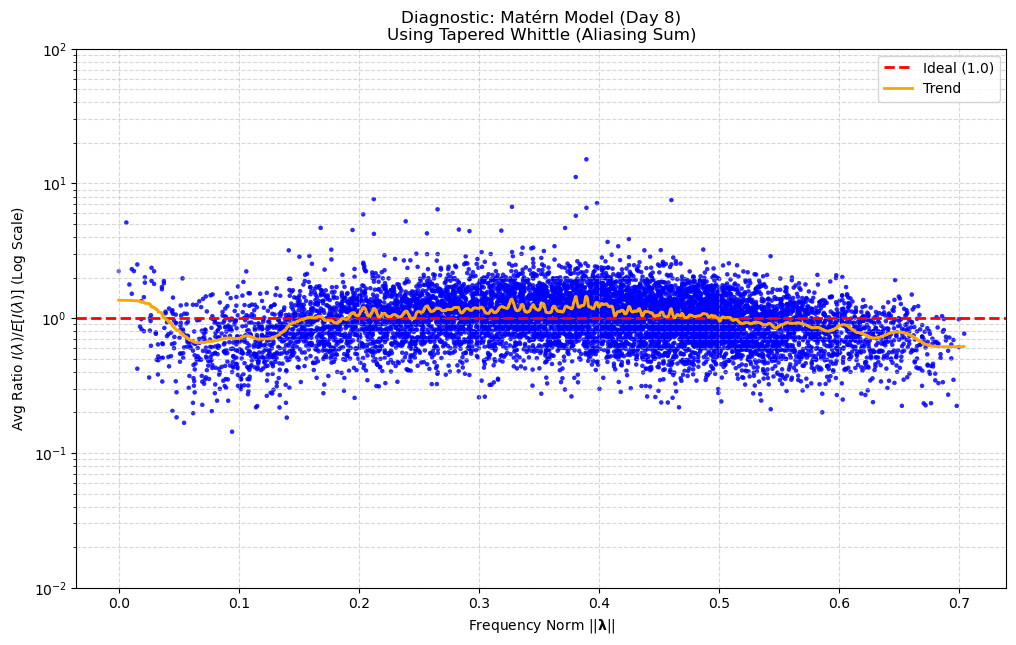

In [15]:


# =========================================================================
# 3. Main Execution Logic for Plotting
# =========================================================================
if __name__ == '__main__':
    # --- Configuration ---
    DAY_TO_RUN = 8
    # Note: Use the Hamming taper from your new class
    TAPERING_FUNC = debiased_whittle_likelihood.cgn_hamming 
    
    # 💥 CRITICAL: Define Deltas corresponding to your grid resolution
    DELTA_LAT = 0.044 
    DELTA_LON = 0.063
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Running on: {DEVICE}")

    print(f"--- Day {DAY_TO_RUN} Diagnostic Plot (New Multivariate Tapered Logic) ---")
    
    # --- Define Parameters (Must be the 7 physical params) ---
    # Example: [sigma_sq, range_lat, range_lon, range_time, advec_lat, advec_lon, nugget]
    # We must convert these to the LOG parameters required by the kernel
    
    # Physical Values
    sigma_sq_val = 11.81
    range_lat_val = 0.26
    range_lon_val = 0.269
    range_time_val = 1.45
    advec_lat_val = -0.0243
    advec_lon_val = -0.2014
    nugget_val = 0.


    # whittle day 1
    sigma_sq_val = 5.8979
    range_lat_val = 0.1799
    range_lon_val = 0.1867
    range_time_val = 1.0234
    advec_lat_val = -0.0072
    advec_lon_val = 0.0834
    nugget_val = 0.

    # dw day 2
    sigma_sq_val = 12.2788
    range_lat_val = 0.2031
    range_lon_val = 0.23
    range_time_val = 1.508
    advec_lat_val = 0.0043
    advec_lon_val = -0.2981
    nugget_val = 0.


    # vecc day2

    sigma_sq_val = 14.8568
    range_lat_val = 0.2048
    range_lon_val = 0.2283
    range_time_val = 1.6022
    advec_lat_val = -0.0299
    advec_lon_val = -0.2392
    nugget_val = 0.



    # Reparameterization to match kernel expectations:
    # Kernel expects: [log(phi1), log(phi2), log(phi3), log(phi4), advec_lat, advec_lon, log(nugget)]
    phi2 = 1.0 / range_lon_val
    phi1 = sigma_sq_val * phi2
    phi3 = (range_lon_val / range_lat_val)**2
    phi4 = (range_lon_val / range_time_val)**2
    
    best_params_raw = torch.tensor([
        np.log(phi1), 
        np.log(phi2), 
        np.log(phi3), 
        np.log(phi4), 
        advec_lat_val, 
        advec_lon_val, 
        np.log(nugget_val)
    ], device=DEVICE, dtype=torch.float64)

    print(f"Params (Log-Space) on device: {best_params_raw}")

    # --- Data Preparation ---
    # ⚠️ ASSUMING 'subsetted_aggregated_day' IS LOADED IN YOUR ENVIRONMENT
    # If testing standalone, replace this with mock data loading
    try:
        cur_df = subsetted_aggregated_day[DAY_TO_RUN - 1] # Ensure 0-indexed
        cur_df =  subsetted_aggregated_day
        unique_times = torch.unique(cur_df[:, 3])
        tensor_list = [cur_df[cur_df[:, 3] == t_val] for t_val in unique_times]
    except NameError:
        print("Error: 'subsetted_aggregated_day' not found. Please load data first.")
        sys.exit(1)

    # --- Step 1: Generate J-Vector & Taper Grid ---
    print("Generating J-Vector and Taper Grid...")
    J_vec, n1, n2, p_time, taper_grid = debiased_whittle_likelihood.generate_Jvector_tapered(
        tensor_list, TAPERING_FUNC, lat_col=0, lon_col=1, val_col=2, device=DEVICE
    )
    print(f"Grid: {n1}x{n2}, Time Points: {p_time}")

    # --- Step 2: Sample Periodogram ---
    print("Calculating Sample Periodogram...")
    # J_vec is (n1, n2, p) -> I_sample is (n1, n2, p, p)
    I_sample = debiased_whittle_likelihood.calculate_sample_periodogram_vectorized(J_vec)
    
    # --- Step 3: Taper Autocorrelation (Critical for New Expectation) ---
    print("Calculating Taper Autocorrelation...")
    taper_autocorr_grid = debiased_whittle_likelihood.calculate_taper_autocorrelation_fft(
        taper_grid, n1, n2, DEVICE
    )

    # --- Step 4: Expected Periodogram ---
    print("Calculating Expected Periodogram (Using Aliasing Sum)...")
    # Returns (n1, n2, p, p) real tensor
    with torch.no_grad():
        I_expected = debiased_whittle_likelihood.expected_periodogram_fft_tapered(
            best_params_raw, n1, n2, p_time, taper_autocorr_grid, DELTA_LAT, DELTA_LON
        )

    # --- Step 5: Plotting Prep (Shift & Diagonal) ---
    # Shift dimensions 0 and 1 (spatial dims). Dims 2 and 3 are time (p x p).
    I_sample_shifted = torch.fft.fftshift(I_sample, dim=(0, 1))
    I_expected_shifted = torch.fft.fftshift(I_expected, dim=(0, 1))

    # We take the diagonal of the p x p time matrix (auto-spectra at each spatial freq)
    # Result is (n1, n2, p)
    diag_sample = torch.diagonal(I_sample_shifted, dim1=-2, dim2=-1).real
    diag_expected = torch.diagonal(I_expected_shifted, dim1=-2, dim2=-1) # Already real

    epsilon = 1e-15
    ratio_grid = diag_sample / (diag_expected + epsilon)
    
    # Average over time steps (optional, or plot specific time step)
    ratio_magnitude_avg = torch.mean(ratio_grid, dim=-1).cpu().numpy()

    # --- Step 6: Visualization ---
    freq_lat = np.fft.fftfreq(n1)
    freq_lon = np.fft.fftfreq(n2)
    freq_lon_shifted, freq_lat_shifted = fftshift(freq_lon), fftshift(freq_lat)
    freq_grid_lon, freq_grid_lat = np.meshgrid(freq_lon_shifted, freq_lat_shifted)
    frequency_norm = np.sqrt(freq_grid_lat**2 + freq_grid_lon**2)
    
    norm_flat = frequency_norm.flatten()
    ratio_flat = ratio_magnitude_avg.flatten()

    plt.figure(figsize=(12, 7))
    plt.scatter(norm_flat, ratio_flat, s=10, alpha=0.6, c='blue', edgecolors='none')
    plt.axhline(1.0, color='r', linestyle='--', linewidth=2, label='Ideal (1.0)')
    
    # Add smoothing trend line (optional)
    try:
        from scipy.ndimage import gaussian_filter1d
        sorted_indices = np.argsort(norm_flat)
        plt.plot(norm_flat[sorted_indices], 
                 gaussian_filter1d(ratio_flat[sorted_indices], sigma=50), 
                 color='orange', linewidth=2, label='Trend')
    except ImportError:
        pass

    plt.yscale('log')
    plt.ylim(1e-2, 1e2)
    plt.title(f'Diagnostic: Matérn Model (Day {DAY_TO_RUN})\nUsing Tapered Whittle (Aliasing Sum)')
    plt.xlabel(r'Frequency Norm $||\boldsymbol{\lambda}||$')
    plt.ylabel(r'Avg Ratio $I(\lambda) / E[I(\lambda)]$ (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", ls="--", alpha=0.5)
    
    print(f"\nStats: Mean={np.mean(ratio_flat):.2f}, Median={np.median(ratio_flat):.2f}")
    plt.show()

univariate

--- Day 1 Diagnostic Plot for Matérn (nu=0.5) ---
Using parameters: [13.06, 0.154, 0.195, 1.0, 0.0218, -0.1689, 0.247]
Data grid: 113x158 spatial points, 8 time points.

Stats: Mean=0.85


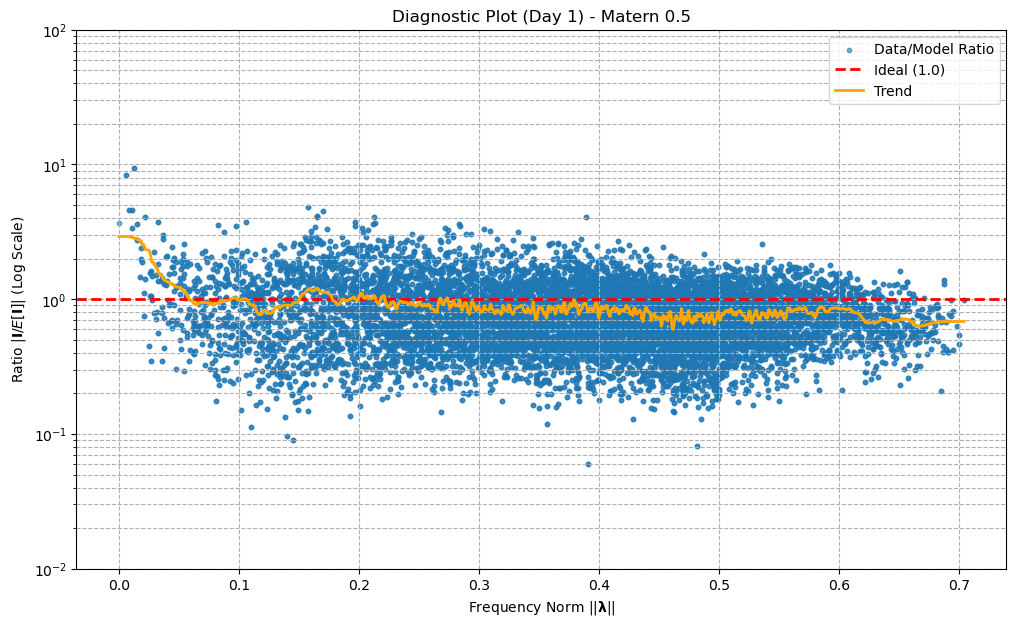

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fftshift
import cmath
import sys

# =========================================================================
# 1. Tapering and Modeling Functions
# =========================================================================

def cgn_hamming(u, n1, n2):
    """Computes a 2D Hamming window."""
    u1, u2 = u
    u1_tensor = u1 if isinstance(u1, torch.Tensor) else torch.tensor(u1, dtype=torch.float32)
    u2_tensor = u2 if isinstance(u2, torch.Tensor) else torch.tensor(u2, dtype=torch.float32)
    hamming1 = 0.54 + 0.46 * torch.cos(2 * torch.pi * u1_tensor / n1)
    hamming2 = 0.54 + 0.46 * torch.cos(2 * torch.pi * u2_tensor / n2)
    return hamming1 * hamming2

def cgn_2dbartlett(u, n1, n2):
    """Computes a 2D Bartlett window function (triangular window)."""
    u1, u2 = u
    return (1 - torch.abs(u1) / n1) * (1 - torch.abs(u2) / n2) 

def cov_x(u1, u2, t, params, nu=0.5):
    """
    Covariance function for PLOTTING using the Matérn model (nu=0.5 / Exponential).
    It expects parameters in their PHYSICAL (Natural) space.
    """
    # Unpack the 7 parameters (Order must match your optimization output)
    # [sigma_sq, range_lat, range_lon, range_time, advec_lat, advec_lon, nugget]
    sigmasq   = params[0]
    range_lat = params[1]
    range_lon = params[2]
    range_time= params[3]
    advec_lat = params[4]
    advec_lon = params[5]
    nugget    = params[6]
    
    # Advection Logic
    u1_adv = u1 - advec_lat * t
    u2_adv = u2 - advec_lon * t
    
    # Distance Calculation (Standardized by ranges)
    # Note: range_time is used here. If you use beta, replace (t/range_time) with (t*beta)
    distance_sq = (u1_adv / range_lat)**2 + (u2_adv / range_lon)**2 + (t / range_time)**2
    distance = torch.sqrt(distance_sq + 1e-12)
    
    # --- 💥 CHANGE: Exponential Kernel (Nu=0.5) ---
    # Formula: sigma^2 * exp(-d)
    matern_cov = sigmasq * torch.exp(-distance)
    
    # Add Nugget at lag 0
    # Note: If distance is ~0, covariance is sigma^2 + nugget
    return torch.where(distance_sq > 1e-9, matern_cov, sigmasq + nugget)

def cov_first_difference(u1, u2, t, params, nu):
    """Computes the autocovariance of the first-difference-filtered process."""
    
    # 💥 CRITICAL: Use your specific grid resolution
    delta1, delta2 = 0.044, 0.063
    
    # Weights for spatial first difference
    stencil_weights = {(0, 0): -2, (1, 0): 1, (0, 1): 1}
    
    cov = torch.zeros_like(u1, dtype=torch.float32)
    
    for (a, b), w_ab in stencil_weights.items():
        for (c, d), w_cd in stencil_weights.items():
            # Apply resolution scaling to lags
            offset_x = (a - c) * delta1
            offset_y = (b - d) * delta2
            
            lag_x = u1 + offset_x
            lag_y = u2 + offset_y
            
            cov += w_ab * w_cd * cov_x(lag_x, lag_y, t, params, nu)
    return cov

def cn_bar(u1, u2, t, params, n1, n2, taper_func, nu):
    """Computes the tapered covariance for the filtered field."""
    u = (u1, u2)
    # Note: u1, u2 here are PHYSICAL lags (already scaled by delta in expected_periodogram)
    # OR they are indices. In this script, 'expected_periodogram' passes INDICES.
    # So 'cov_first_difference' must handle the scaling. 
    # Current setup: cov_first_difference applies deltas to the OFFSETS, 
    # but assumes u1, u2 are already physical.
    # Let's fix this in the main loop below.
    return cov_first_difference(u1, u2, t, params, nu) * taper_func(u, n1, n2)

def expected_periodogram_fft_multivariate(params, n1, n2, p, taper_func, nu, delta1=0.044, delta2=0.063):
    """Calculates the expected periodogram for the FILTERED field."""
    product_tensor = torch.zeros((n1, n2, p, p), dtype=torch.complex64)
    t_lags = torch.arange(p, dtype=torch.float32)
    
    # Create Index Mesh
    u1_idx, u2_idx = torch.meshgrid(torch.arange(n1, dtype=torch.float32), torch.arange(n2, dtype=torch.float32), indexing='ij')

    # Convert Indices to Physical Distances for the covariance function
    u1_phys = u1_idx * delta1
    u2_phys = u2_idx * delta2

    for q in range(p):
        for r in range(p):
            t = t_lags[q] - t_lags[r]
            # Pass Physical Lags to covariance, but Grid Indices to Taper
            cov_val = cov_first_difference(u1_phys, u2_phys, t, params, nu)
            taper_val = taper_func((u1_idx, u2_idx), n1, n2)
            
            product_tensor[:, :, q, r] = cov_val * taper_val

    fft_result = torch.fft.fft2(product_tensor, dim=(-4, -3))
    normalization_factor = 1 / (2 * cmath.pi)**2
    return fft_result * normalization_factor

# =========================================================================
# 2. Data Processing Functions
# =========================================================================
def generate_Jvector_final(tensor_list, taper_func, lat_col=0, lon_col=1, val_col=2):
    p = len(tensor_list)
    if p == 0:
        return torch.empty(0, 0, 0), 0, 0, 0

    all_lats = torch.cat([t[:, lat_col] for t in tensor_list])
    all_lons = torch.cat([t[:, lon_col] for t in tensor_list])
    unique_lats, unique_lons = torch.unique(all_lats), torch.unique(all_lons)
    n1, n2 = len(unique_lats), len(unique_lons)

    lat_map = {lat.item(): i for i, lat in enumerate(unique_lats)}
    lon_map = {lon.item(): i for i, lon in enumerate(unique_lons)}

    u1_mesh, u2_mesh = torch.meshgrid(torch.arange(n1, dtype=torch.float32), torch.arange(n2, dtype=torch.float32), indexing='ij')
    taper_grid = taper_func((u1_mesh, u2_mesh), n1, n2)

    fft_results = []
    for tensor in tensor_list:
        data_grid = torch.zeros((n1, n2), dtype=torch.float32)
        for row in tensor:
             i = lat_map[row[lat_col].item()]
             j = lon_map[row[lon_col].item()]
             data_grid[i, j] = row[val_col]
        
        data_grid_tapered = data_grid * taper_grid
        fft_results.append(torch.fft.fft2(data_grid_tapered))

    J_vector_tensor = torch.stack(fft_results, dim=2)

    H = torch.sum(taper_grid**2)
    norm_factor = torch.sqrt(1 / H) / (2 * cmath.pi)
    
    return J_vector_tensor * norm_factor, n1, n2, p

def calculate_sample_periodogram_vectorized(J_vector_tensor):
    """Efficient vectorized version."""
    J_col = J_vector_tensor.unsqueeze(-1)
    J_row_conj = J_vector_tensor.unsqueeze(-2).conj()
    return J_col @ J_row_conj

# =========================================================================
# 3. Main Execution Logic
# =========================================================================
if __name__ == '__main__':
    # --- Configuration ---
    DAY_TO_RUN = 1
    TAMPERING_FUNC = cgn_2dbartlett # Or switch to cgn_hamming
    NU_SMOOTHNESS = 0.5 
    
    print(f"--- Day {DAY_TO_RUN} Diagnostic Plot for Matérn (nu={NU_SMOOTHNESS}) ---")
    
    # --- Params (Physical Space) ---
    # [sigma_sq, range_lat, range_lon, range_time, advec_lat, advec_lon, nugget]
    # Update these with your fit_vecchia_lbfgs output
    best_params = [13.06, 0.154, 0.195, 1.0, 0.0218, -0.1689, 0.247] 
    
    print(f"Using parameters: {best_params}")
    
    # --- Data Loading (Placeholder: Ensure subsetted_aggregated_day is available) ---
    try:
        cur_df = subsetted_aggregated_day[DAY_TO_RUN - 1]
        cur_df = subsetted_aggregated_day
        unique_times = torch.unique(cur_df[:, 3])
        tensor_list = [cur_df[cur_df[:, 3] == t_val] for t_val in unique_times]
    except NameError:
        print("Error: 'subsetted_aggregated_day' variable not found. Please load your data.")
        sys.exit(1)
    
    # --- Calculation ---
    J_vec, n1, n2, p = generate_Jvector_final(tensor_list, TAMPERING_FUNC, lat_col=0, lon_col=1, val_col=2)
    print(f"Data grid: {n1}x{n2} spatial points, {p} time points.")
    
    I_sample = calculate_sample_periodogram_vectorized(J_vec)
    
    # Pass Deltas Explicitly here
    I_expected = expected_periodogram_fft_multivariate(
        best_params, n1, n2, p, TAMPERING_FUNC, 
        nu=NU_SMOOTHNESS, delta1=0.044, delta2=0.063
    )

    # Shift for plotting
    I_sample_shifted = torch.fft.fftshift(I_sample, dim=(-4, -3))
    I_expected_shifted = torch.fft.fftshift(I_expected, dim=(-4, -3))
    
    # Diagonal ratio
    epsilon = 1e-15
    ratio_complex = I_sample_shifted / (I_expected_shifted + epsilon)
    diagonal_ratio = torch.diagonal(ratio_complex, dim1=-2, dim2=-1) 
    ratio_magnitude_avg = torch.mean(torch.abs(diagonal_ratio), dim=-1)
    
    # --- Plotting ---
    freq_lat = np.fft.fftfreq(n1)
    freq_lon = np.fft.fftfreq(n2)
    freq_lon_shifted, freq_lat_shifted = fftshift(freq_lon), fftshift(freq_lat)
    freq_grid_lon, freq_grid_lat = np.meshgrid(freq_lon_shifted, freq_lat_shifted)
    frequency_norm = np.sqrt(freq_grid_lat**2 + freq_grid_lon**2)
    
    norm_flat = frequency_norm.flatten()
    ratio_flat = ratio_magnitude_avg.detach().numpy().flatten()

    plt.figure(figsize=(12, 7))
    plt.scatter(norm_flat, ratio_flat, s=10, alpha=0.6, label='Data/Model Ratio')
    plt.axhline(1.0, color='r', linestyle='--', linewidth=2, label='Ideal (1.0)')
    
    # Add trend line
    from scipy.ndimage import gaussian_filter1d
    sorted_idx = np.argsort(norm_flat)
    plt.plot(norm_flat[sorted_idx], gaussian_filter1d(ratio_flat[sorted_idx], sigma=30), 
             color='orange', linewidth=2, label='Trend')

    plt.yscale('log')
    plt.ylim(1e-2, 1e2)
    plt.title(f'Diagnostic Plot (Day {DAY_TO_RUN}) - Matern 0.5')
    plt.xlabel(r'Frequency Norm $||\boldsymbol{\lambda}||$')
    plt.ylabel(r'Ratio $|\mathbf{I} / E[\mathbf{I}]|$ (Log Scale)')
    plt.legend()
    plt.grid(True, which="both", ls="--")
    
    print(f"\nStats: Mean={np.mean(ratio_flat):.2f}")
    plt.show()